In [16]:
import lgdo
import lh5
import numpy as np
import awkward as ak
import os
import re

In [17]:
filepath = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "00"
run_cal = "037"

pnum_phy_bg = "00"
run_phy_bg = "038"

pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
    's100ns_mw1', 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
    's200ns_mw1', 's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    's60ns_mw1',  's60ns_mw3',  's60ns_mw5',  's60ns_mw7'
]

def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)
        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")

        missing_this_run = []

        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")

        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "interval": f"{m.group(1)}ns",
            "mw": f"mw{m.group(2)}",

            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,

            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,

            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )

    return db
run_db = build_run_db(runs, filepath)

In [28]:
run = 's100ns_mw5'
pathlist = 'phy_bg_pathlist'

In [29]:
E_1=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run][pathlist])
A_max_mw_o_E_Classifier_1=lh5.read("ch002/hit/A_max_mw_o_E_Classifier",run_db[run][pathlist])
Iasy_std = lh5.read("ch002/hit/Iasy",run_db['s100ns_mw5'][pathlist])
is_valid_waveform_1= lh5.read("ch002/hit/is_valid_waveform",run_db['s100ns_mw5'][pathlist])
# A_max_mw_o_E_High_Side_Cut_std = lh5.read("ch002/hit/A_max_mw_o_E_High_Side_Cut",run_db['s100ns_mw5'][pathlist])

In [30]:
E_1 = np.asarray(E_1)
# A_max_mw_o_E_High_Side_Cut_std = np.asarray(A_max_mw_o_E_High_Side_Cut_std)
Iasy_std = np.asarray(Iasy_std)
A_max_mw_o_E_Classifier_1= np.asarray(A_max_mw_o_E_Classifier_1)
is_valid_waveform_1 = np.asarray(is_valid_waveform_1)

In [31]:
run = 's200ns_mw7'

In [32]:
E_2=lh5.read("ch002/hit/trapEftp_fix_cal",run_db[run][pathlist])
A_max_mw_o_E_Classifier_2=lh5.read("ch002/hit/A_max_mw_o_E_Classifier",run_db[run][pathlist])
Iasy_std = lh5.read("ch002/hit/Iasy",run_db['s100ns_mw5'][pathlist])
is_valid_waveform_2 = lh5.read("ch002/hit/is_valid_waveform",run_db[run][pathlist])
# A_max_mw_o_E_High_Side_Cut_std = lh5.read("ch002/hit/A_max_mw_o_E_High_Side_Cut",run_db['s100ns_mw5'][pathlist])

In [33]:
E_2 = np.asarray(E_2)
# A_max_mw_o_E_High_Side_Cut_std = np.asarray(A_max_mw_o_E_High_Side_Cut_std)
Iasy_std = np.asarray(Iasy_std)
A_max_mw_o_E_Classifier_2 = np.asarray(A_max_mw_o_E_Classifier_2)
is_valid_waveform_std = np.asarray(is_valid_waveform_2)

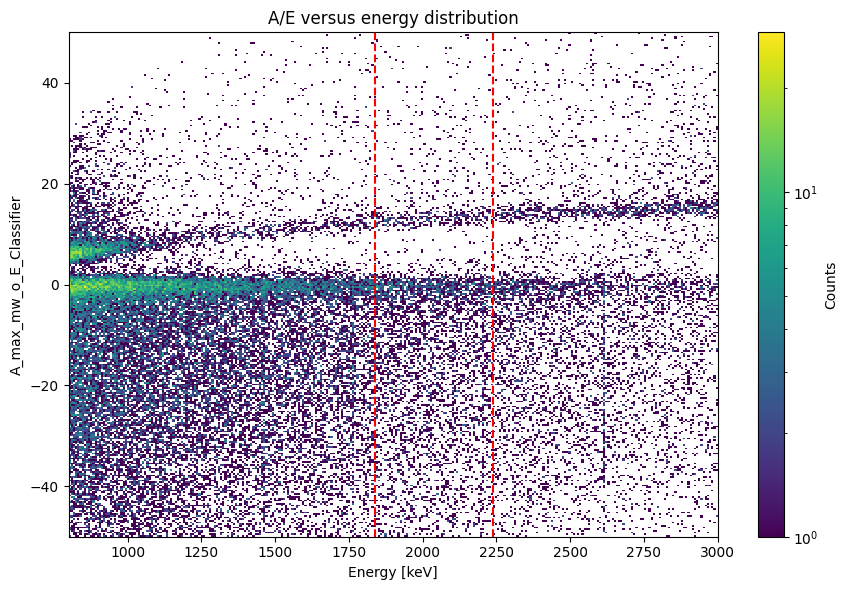

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

is_not_alpha = Iasy_std<0 & is_valid_waveform_std
fig, ax = plt.subplots(figsize=(9, 6))
# E_mask_1 = (
#     (E_1 <= 1590)
#     | (E_1 >= 1610)
# )
hist = ax.hist2d(
    # E_std[is_not_alpha],
    # aoe[is_not_alpha], #without alphas
    # E_1[is_valid_waveform_std&E_mask_1],
    # A_max_mw_o_E_Classifier_1[is_valid_waveform_std&E_mask_1], #with alphas
    E_1[is_valid_waveform_std],
    A_max_mw_o_E_Classifier_1[is_valid_waveform_std], #with alphas
    
    bins=(300, 300),          # (energy bins, A/E bins)
    range=((800, 3000), (-50, 50)),
    norm=LogNorm(),           # logarithmic count color scale
    cmap="viridis",
)

cbar = fig.colorbar(hist[3], ax=ax)
cbar.set_label("Counts")

ax.set_xlabel("Energy [keV]")
ax.set_ylabel("A_max_mw_o_E_Classifier")
ax.set_title("A/E versus energy distribution")
ax.axvline(1839,linestyle='--',c='red')
ax.axvline(2239,linestyle="--",c='red')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1425564/1196596235.py:101: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


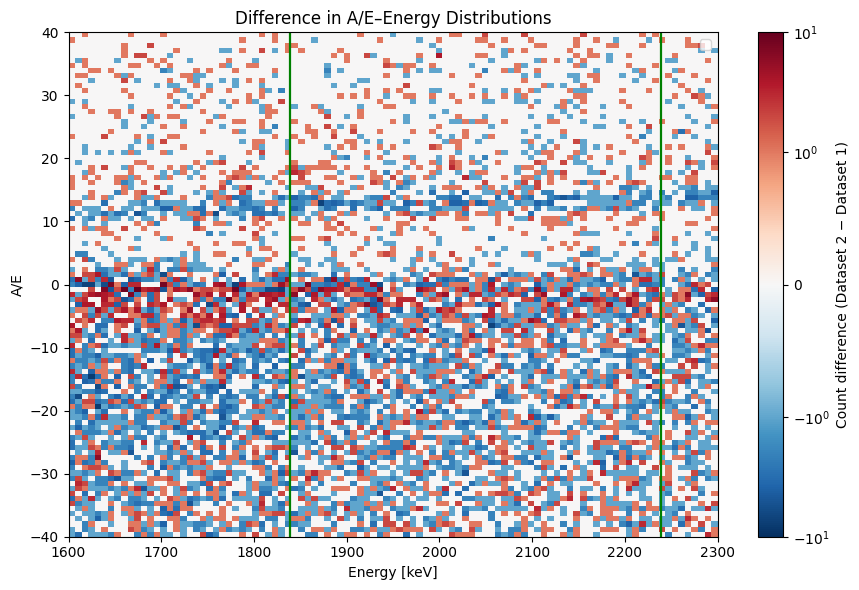

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

# Identical bin edges for both histograms
energy_edges = np.linspace(1600, 2300, 100)
aoe_edges = np.linspace(-40, 40, 100)
# E_mask_1 = (
#     (E_1 <= 1610)
#     | (E_1 >= 1590)
# )
# E_mask_2 = (
#     (E_2 <= 1610)
#     | (E_2 >= 1590)
# )
H1, _, _ = np.histogram2d(
    # E_1[is_valid_waveform_1&E_mask_1], A_max_mw_o_E_Classifier_1[is_valid_waveform_1&E_mask_1],
    E_1[is_valid_waveform_1], A_max_mw_o_E_Classifier_1[is_valid_waveform_1],
    # E_1[is_valid_waveform_1], A_max_mw_o_E_Classifier_1[is_valid_waveform_1],
    
    bins=(energy_edges, aoe_edges)
)

H2, _, _ = np.histogram2d(
    # E_2[is_valid_waveform_2&E_mask_2], A_max_mw_o_E_Classifier_2[is_valid_waveform_2&E_mask_2],
    E_2[is_valid_waveform_2], A_max_mw_o_E_Classifier_2[is_valid_waveform_2],
    # E_2[is_valid_waveform_2], A_max_mw_o_E_Classifier_2[is_valid_waveform_2],
    bins=(energy_edges, aoe_edges)
)

# Positive: more counts in dataset 2
# Negative: more counts in dataset 1
difference = H2 - H1

limit = np.max(np.abs(difference))

fig, ax = plt.subplots(figsize=(9, 6))

limit = max(np.max(np.abs(difference)), 1)

mesh = ax.pcolormesh(
    energy_edges,
    aoe_edges,
    difference.T,
    cmap="RdBu_r",
    norm=SymLogNorm(
        linthresh=1,     # Linear region between -1 and +1
        linscale=1,
        vmin=-limit,
        vmax=limit,
        base=10,
    ),
    shading="auto",
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Count difference (Dataset 2 − Dataset 1)")

ax.set_xlabel("Energy [keV]")
ax.set_ylabel("A/E")
ax.set_title("Difference in A/E–Energy Distributions")

# Nominal Tl-208 peak energies and slightly wider plotting regions
peak_regions = {
    "ROI": {
        # "center": 1592.5,
        "range": (1839, 2239),
        "color": "green",
    },
    # "SEP (2103.5 keV)": {
    #     "center": 2103.5,
    #     "range": (2070, 2125),
    #     "color": "red",
    # },
    # "FEP (2614.5 keV)": {
    #     "center": 2614.5,
    #     "range": (2575, 2640),
    #     "color": "red",
    # },
}

for label, peak in peak_regions.items():
    low, high = peak["range"]
    color = peak["color"]
    # Region boundaries
    ax.axvline(
        low,
        color=color,
        linestyle="-",
        linewidth=1.6,
        alpha=1,
    )
    ax.axvline(
        high,
        color=color,
        linestyle="-",
        linewidth=1.6,
        alpha=1,
    )

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [36]:
print("Minimum:", np.nanmin(difference))
print("Maximum:", np.nanmax(difference))
print("NaNs:", np.isnan(difference).sum())

Minimum: -8.0
Maximum: 10.0
NaNs: 0
